In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, accuracy_score, r2_score, mean_absolute_error
from sklearn import metrics

In [ ]:
df=pd.read_csv('movie_metadata.csv')


In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
df

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,CCH Pounder,Avatar,886204,4834,Wes Studi,0.0,avatar|future|marine|native|paraplegic,http://www.imdb.com/title/tt0499549/?ref_=fn_t...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,Johnny Depp,Pirates of the Caribbean: At World's End,471220,48350,Jack Davenport,0.0,goddess|marriage ceremony|marriage proposal|pi...,http://www.imdb.com/title/tt0449088/?ref_=fn_t...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,Christoph Waltz,Spectre,275868,11700,Stephanie Sigman,1.0,bomb|espionage|sequel|spy|terrorist,http://www.imdb.com/title/tt2379713/?ref_=fn_t...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,Tom Hardy,The Dark Knight Rises,1144337,106759,Joseph Gordon-Levitt,0.0,deception|imprisonment|lawlessness|police offi...,http://www.imdb.com/title/tt1345836/?ref_=fn_t...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,Doug Walker,Star Wars: Episode VII - The Force Awakens ...,8,143,NaN,0.0,NaN,http://www.imdb.com/title/tt5289954/?ref_=fn_t...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5038,Color,Scott Smith,1.0,87.0,2.0,318.0,Daphne Zuniga,637.0,NaN,Comedy|Drama,Eric Mabius,Signed Sealed Delivered,629,2283,Crystal Lowe,2.0,fraud|postal worker|prison|theft|trial,http://www.imdb.com/title/tt3000844/?ref_=fn_t...,6.0,English,Canada,NaN,NaN,2013.0,470.0,7.7,NaN,84
5039,Color,NaN,43.0,43.0,NaN,319.0,Valorie Curry,841.0,NaN,Crime|Drama|Mystery|Thriller,Natalie Zea,The Following,73839,1753,Sam Underwood,1.0,cult|fbi|hideout|prison escape|serial killer,http://www.imdb.com/title/tt2071645/?ref_=fn_t...,359.0,English,USA,TV-14,NaN,NaN,593.0,7.5,16.00,32000
5040,Color,Benjamin Roberds,13.0,76.0,0.0,0.0,Maxwell Moody,0.0,NaN,Drama|Horror|Thriller,Eva Boehnke,A Plague So Pleasant,38,0,David Chandler,0.0,NaN,http://www.imdb.com/title/tt2107644/?ref_=fn_t...,3.0,English,USA,NaN,1400.0,2013.0,0.0,6.3,NaN,16
5041,Color,Daniel Hsia,14.0,100.0,0.0,489.0,Daniel Henney,946.0,10443.0,Comedy|Drama|Romance,Alan Ruck,Shanghai Calling,1255,2386,Eliza Coupe,5.0,NaN,http://www.imdb.com/title/tt2070597/?ref_=fn_t...,9.0,English,USA,PG-13,NaN,2012.0,719.0,6.3,2.35,660


In [ ]:
df.isnull().sum()

,0
color,19
director_name,104
num_critic_for_reviews,50
duration,15
director_facebook_likes,104
actor_3_facebook_likes,23
actor_2_name,13
actor_1_facebook_likes,7
gross,884
genres,0


In [ ]:
null_percentage = df.isnull().sum() / len(df) * 100

In [ ]:
null_percentage.sort_values(ascending=False)

,0
gross,17.529248
budget,9.756098
aspect_ratio,6.523895
content_rating,6.008328
plot_keywords,3.033908
title_year,2.141582
director_facebook_likes,2.062265
director_name,2.062265
num_critic_for_reviews,0.991473
actor_3_facebook_likes,0.456078


In [ ]:
df.columns

Index(['color', 'director_name', 'num_critic_for_reviews', 'duration',
       'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name',
       'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name',
       'movie_title', 'num_voted_users', 'cast_total_facebook_likes',
       'actor_3_name', 'facenumber_in_poster', 'plot_keywords',
       'movie_imdb_link', 'num_user_for_reviews', 'language', 'country',
       'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes',
       'imdb_score', 'aspect_ratio', 'movie_facebook_likes'],
      dtype='object')

In [ ]:
df['language'].value_counts()

,count
language,
English,4704
French,73
Spanish,40
Hindi,28
Mandarin,26
German,19
Japanese,18
Cantonese,11
Italian,11


In [ ]:
df.movie_title[df.language == 'Hindi']

,movie_title
1056,Earth
3075,Kabhi Alvida Naa Kehna
3085,Housefull
3208,Krrish
3276,Jab Tak Hai Jaan
3344,My Name Is Khan
3348,Namastey London
3350,Yeh Jawaani Hai Deewani
3455,Ta Ra Rum Pum
3510,Veer-Zaara


In [ ]:
bw = df[df.language == 'Hindi']

In [ ]:
bw

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
1056,Color,Deepa Mehta,34.0,110.0,375.0,59.0,Gulshan Grover,113.0,528972.0,Drama|Romance|War,Nandita Das,Earth,5639,371,Eric Peterson,0.0,friend|hindu|india|muslim|sikh,http://www.imdb.com/title/tt0150433/?ref_=fn_t...,55.0,Hindi,India,Unrated,NaN,1998.0,102.0,7.8,NaN,522
3075,Color,Karan Johar,20.0,193.0,160.0,860.0,John Abraham,8000.0,3275443.0,Drama,Shah Rukh Khan,Kabhi Alvida Naa Kehna,13998,10822,Preity Zinta,2.0,extramarital affair|fashion magazine editor|ma...,http://www.imdb.com/title/tt0449999/?ref_=fn_t...,264.0,Hindi,India,R,700000000.0,2006.0,1000.0,6.0,2.35,659
3085,Color,Sajid Khan,10.0,144.0,0.0,119.0,Boman Irani,564.0,1165104.0,Comedy,Arjun Rampal,Housefull,8598,1121,Riteish Deshmukh,5.0,bad luck|casino|lie|mix up|stutter,http://www.imdb.com/title/tt1573072/?ref_=fn_t...,43.0,Hindi,India,NaN,NaN,2010.0,154.0,5.3,NaN,250
3208,Color,Rakesh Roshan,20.0,168.0,53.0,45.0,Rekha,307.0,NaN,Action|Adventure|Romance|Sci-Fi,Naseeruddin Shah,Krrish,12411,616,Sharat Saxena,0.0,breaking the fourth wall|breaking the fourth w...,http://www.imdb.com/title/tt0432637/?ref_=fn_t...,110.0,Hindi,India,Not Rated,10000000.0,2006.0,200.0,6.3,2.35,533
3276,Color,Yash Chopra,50.0,176.0,147.0,1000.0,Katrina Kaif,8000.0,3047539.0,Drama|Romance,Shah Rukh Khan,Jab Tak Hai Jaan,42296,13762,Vic Waghorn,4.0,accident|army|bomb|indian army|love,http://www.imdb.com/title/tt2176013/?ref_=fn_t...,286.0,Hindi,India,Not Rated,7217600.0,2012.0,3000.0,6.9,2.35,12000
3344,Color,Karan Johar,210.0,128.0,160.0,81.0,Jimmy Shergill,8000.0,4018695.0,Adventure|Drama|Thriller,Shah Rukh Khan,My Name Is Khan,69759,8532,Christopher B. Duncan,2.0,airport|asperger's syndrome|autism|muslim|raci...,http://www.imdb.com/title/tt1188996/?ref_=fn_t...,235.0,Hindi,India,PG-13,12000000.0,2010.0,327.0,8.0,2.35,27000
3348,Color,Vipul Amrutlal Shah,15.0,128.0,11.0,119.0,Clive Standen,3000.0,1207007.0,Comedy|Drama|Romance,Katrina Kaif,Namastey London,13577,4004,Riteish Deshmukh,2.0,india|london england|marriage|stereotype|sugar...,http://www.imdb.com/title/tt0795434/?ref_=fn_t...,47.0,Hindi,India,NaN,NaN,2007.0,687.0,7.3,NaN,341
3350,Color,Ayan Mukerji,25.0,160.0,0.0,417.0,Madhuri Dixit,964.0,3827466.0,Comedy|Drama|Musical|Romance,Ranbir Kapoor,Yeh Jawaani Hai Deewani,25122,2350,Aditya Roy Kapoor,2.0,jealousy|jumping into sea|love|swimming pool|w...,http://www.imdb.com/title/tt2178470/?ref_=fn_t...,102.0,Hindi,India,Not Rated,NaN,2013.0,551.0,6.9,NaN,0
3455,Color,Siddharth Anand,16.0,153.0,5.0,60.0,Mary Goggin,532.0,872643.0,Comedy|Family|Romance,Saif Ali Khan,Ta Ra Rum Pum,2909,902,Vic Aviles,3.0,comeback|family relationships|marriage|new yor...,http://www.imdb.com/title/tt0833553/?ref_=fn_t...,37.0,Hindi,USA,NaN,6000000.0,2007.0,249.0,5.4,NaN,108
3510,Color,Yash Chopra,29.0,192.0,147.0,397.0,Preity Zinta,8000.0,2921738.0,Drama|Musical|Romance,Shah Rukh Khan,Veer-Zaara,34449,9984,Anupam Kher,0.0,fair|pakistan|prison|rescue|stranded,http://www.imdb.com/title/tt0420332/?ref_=fn_t...,119.0,Hindi,India,NaN,7000000.0,2004.0,860.0,7.9,2.35,2000


In [ ]:
scores = bw.imdb_score[bw.imdb_score >= 7]

In [ ]:
name = bw.movie_title[bw.imdb_score >= 7]

In [ ]:
genre = bw.genres[bw.imdb_score >= 7]

In [ ]:
bollywoodmovieratings = pd.concat([name,genre,scores], axis=1)

In [ ]:
bollywoodmovieratings

,movie_title,genres,imdb_score
1056,Earth,Drama|Romance|War,7.8
3344,My Name Is Khan,Adventure|Drama|Thriller,8.0
3348,Namastey London,Comedy|Drama|Romance,7.3
3510,Veer-Zaara,Drama|Musical|Romance,7.9
3685,Rang De Basanti,Comedy|Drama|History|Romance,8.4
3789,"Gandhi, My Father",Biography|Drama|History,7.4
3870,Airlift,Action|Drama|History|Thriller|War,8.5
3877,Paa,Comedy|Drama,7.2
4088,Water,Drama|Romance,7.8
4160,Lage Raho Munna Bhai,Comedy|Drama|Romance,8.2


In [ ]:
num_cols = []
cat_cols = []

for col in df.columns:
  if df[col].dtypes != 'object':
    num_cols = num_cols + [col]
  else:
    cat_cols = cat_cols + [col]

print(num_cols)
print(cat_cols)

['num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_1_facebook_likes', 'gross', 'num_voted_users', 'cast_total_facebook_likes', 'facenumber_in_poster', 'num_user_for_reviews', 'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score', 'aspect_ratio', 'movie_facebook_likes']
['color', 'director_name', 'actor_2_name', 'genres', 'actor_1_name', 'movie_title', 'actor_3_name', 'plot_keywords', 'movie_imdb_link', 'language', 'country', 'content_rating']


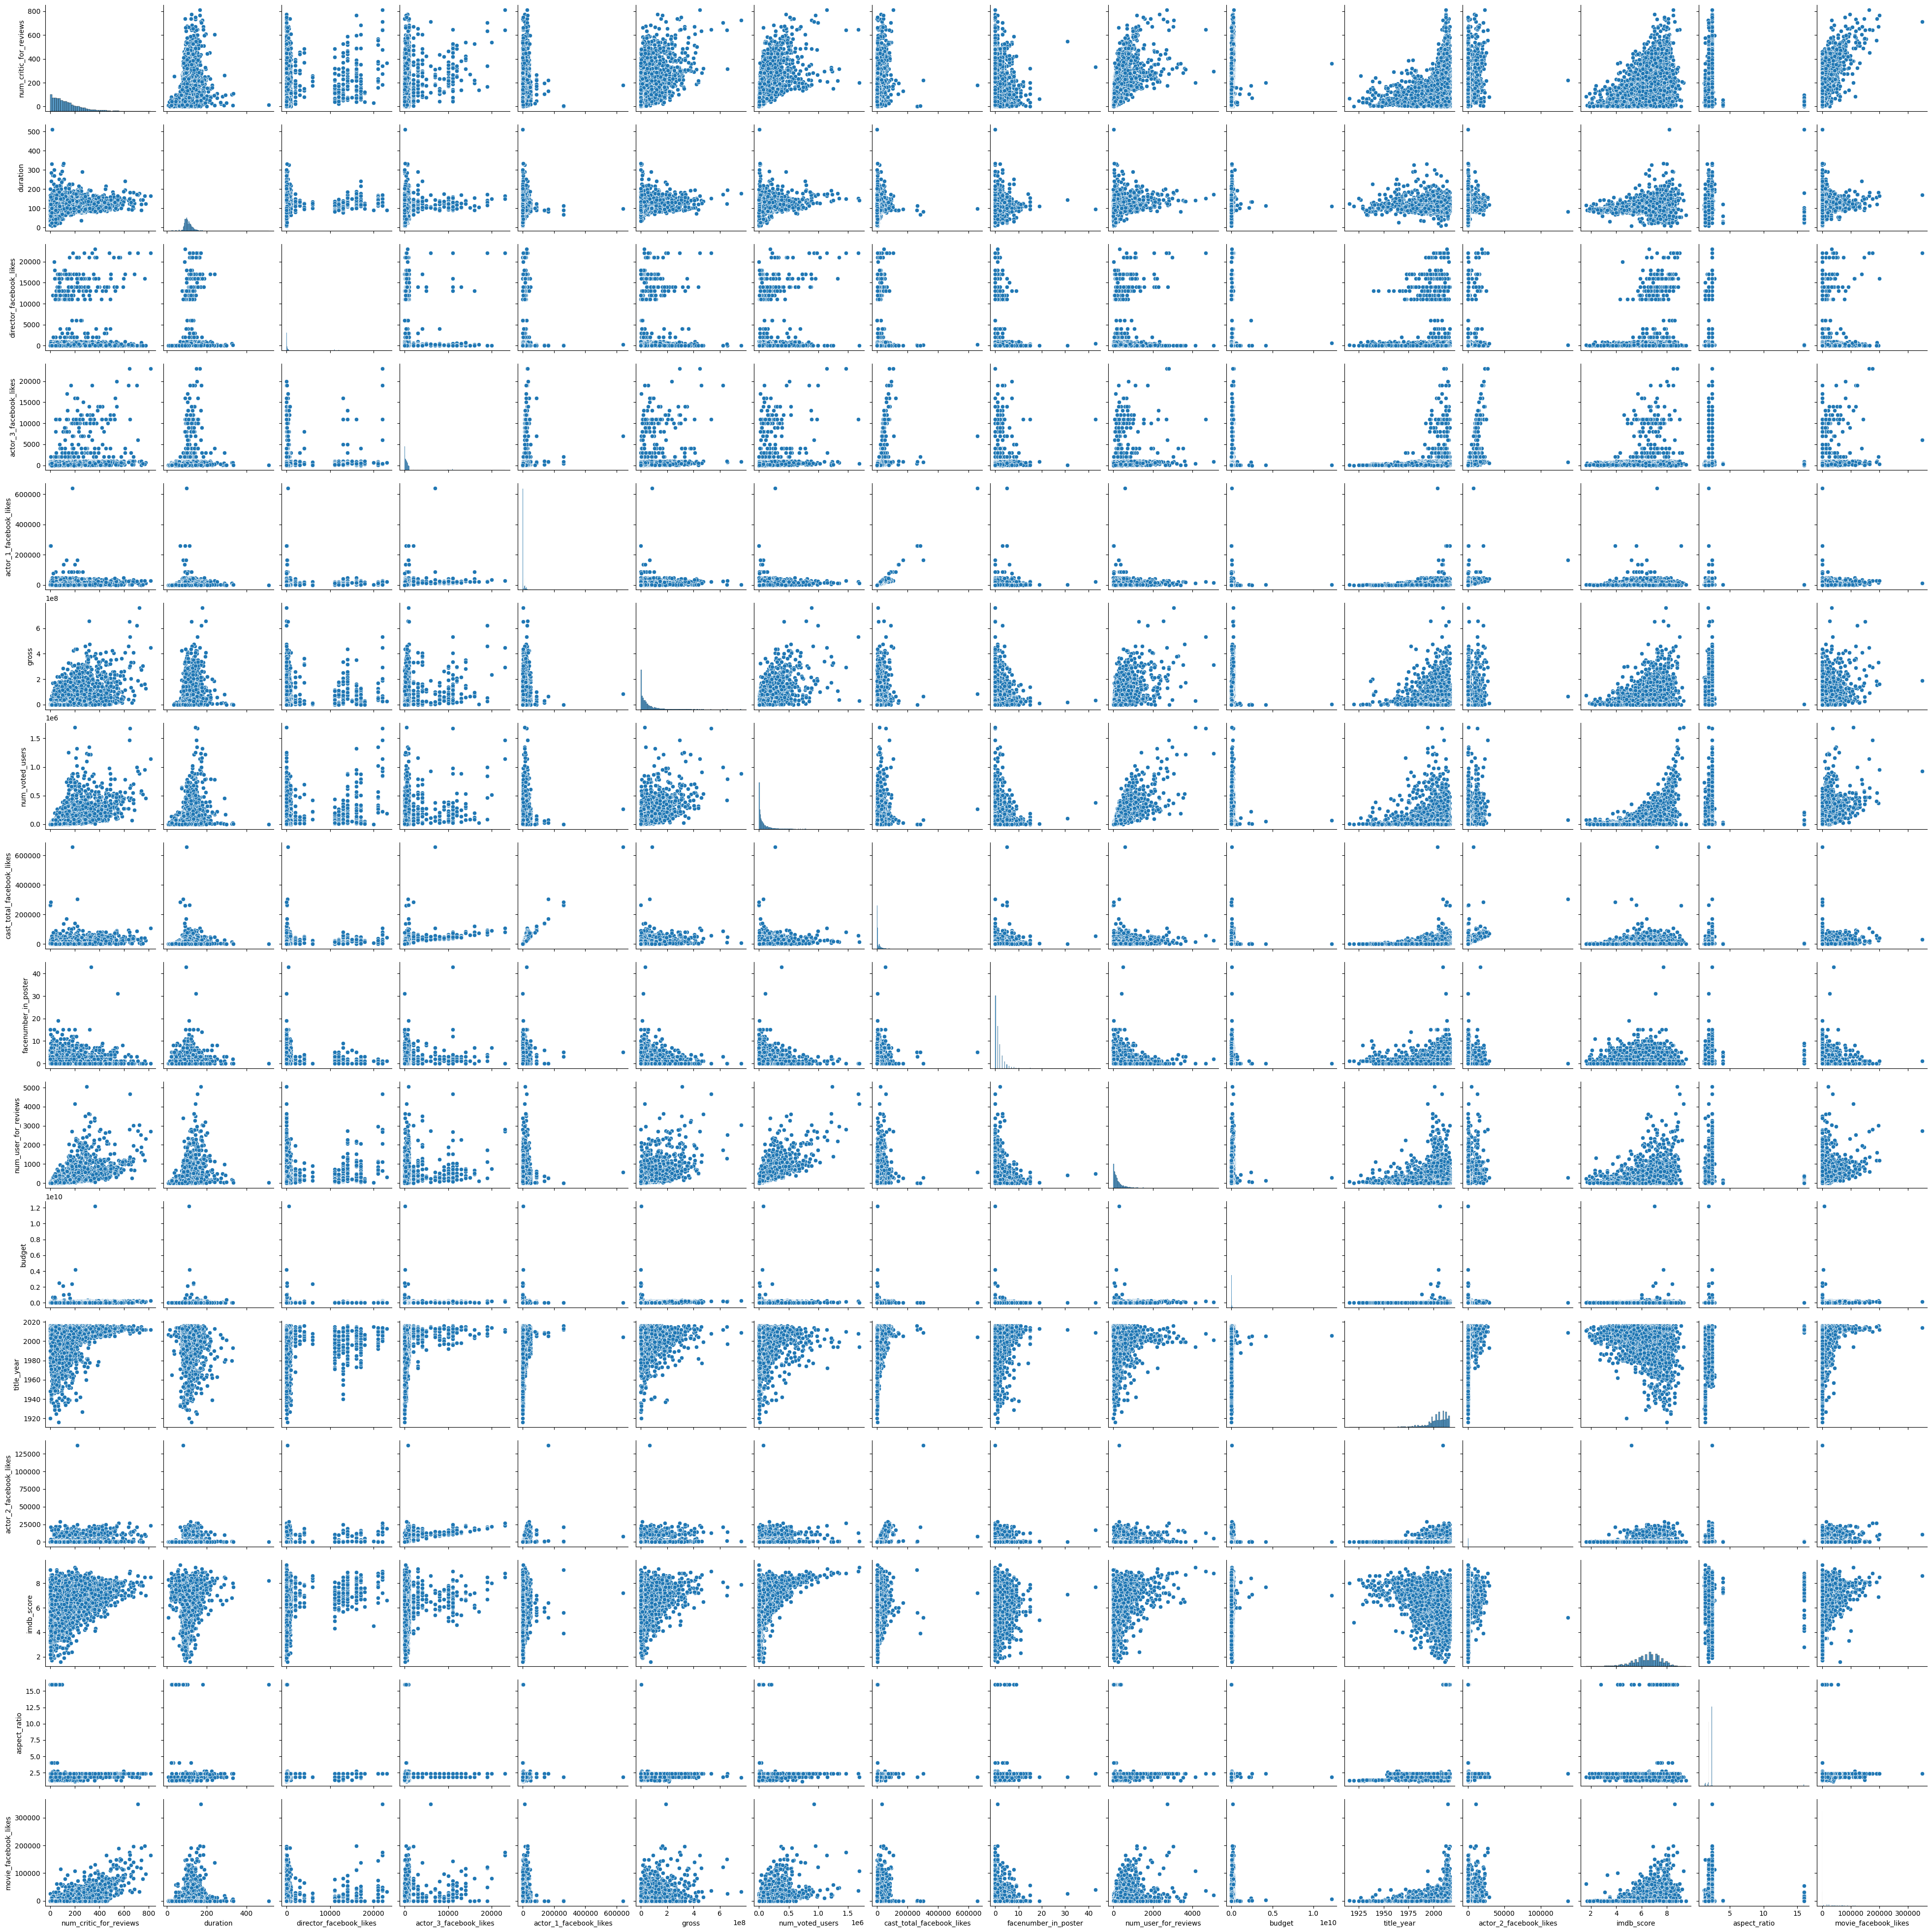

In [ ]:
sns.pairplot(data = df[num_cols])

<Axes: ylabel='count'>

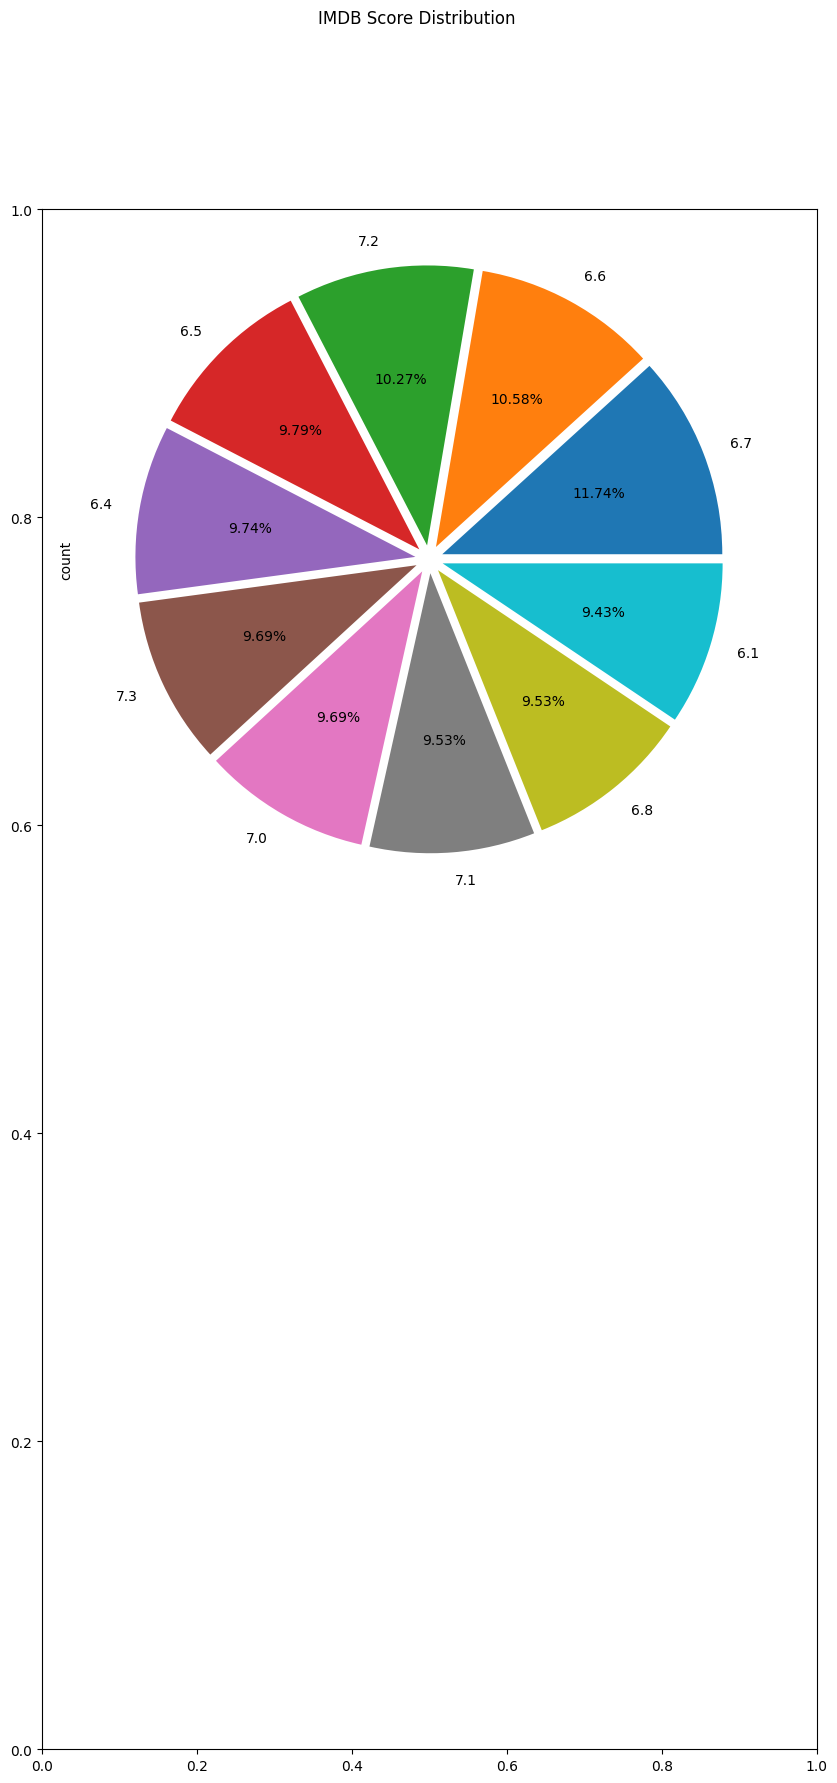

In [ ]:
f, ax = plt.subplots(figsize = (10,20))
ax1 = plt.subplot(211)
f.suptitle("IMDB Score Distribution")
explode = (0.05, 0.05, 0.05, 0.05,0.05,0.05,0.05,0.05,0.05,0.05)
test = df['imdb_score'].value_counts(ascending=False).head(10)
test.plot(kind='pie',autopct="%0.2f%%",explode=explode,ax=ax1)


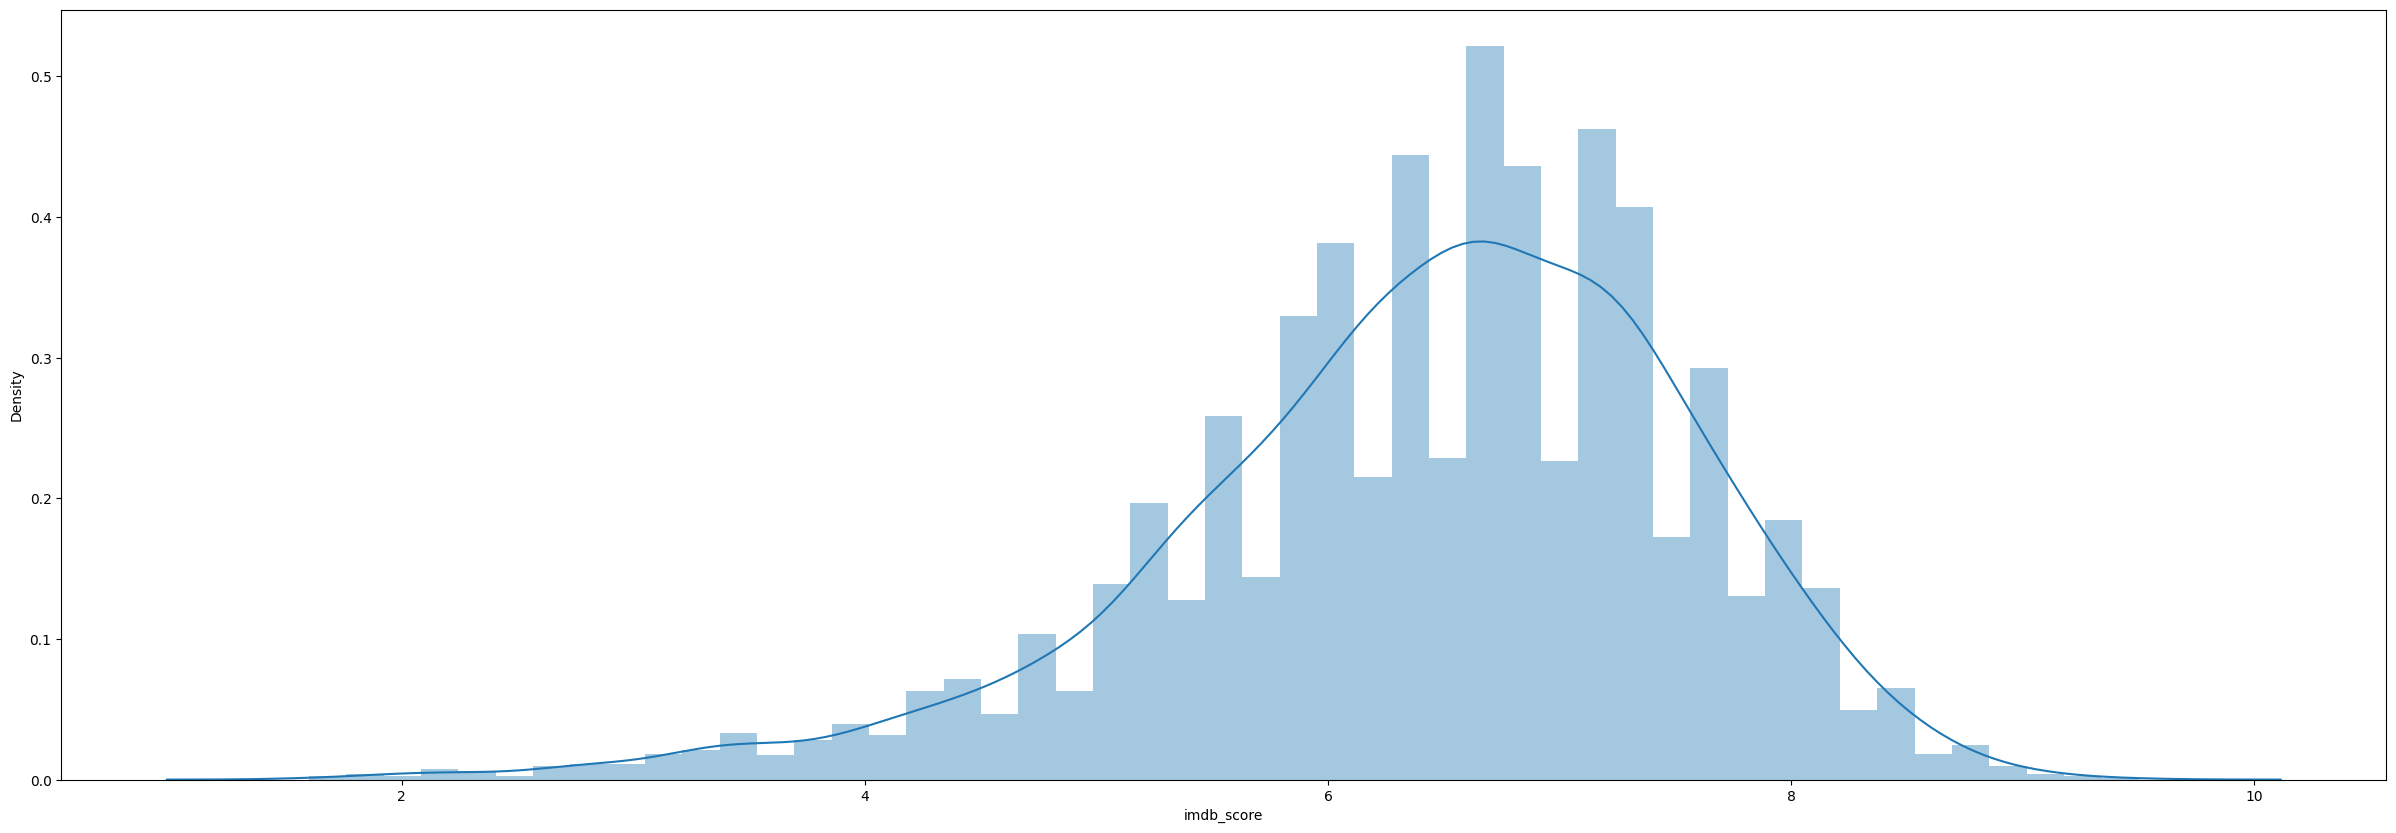

In [ ]:
plt.figure(figsize=(30,10))
sns.distplot(df['imdb_score'])
plt.show()

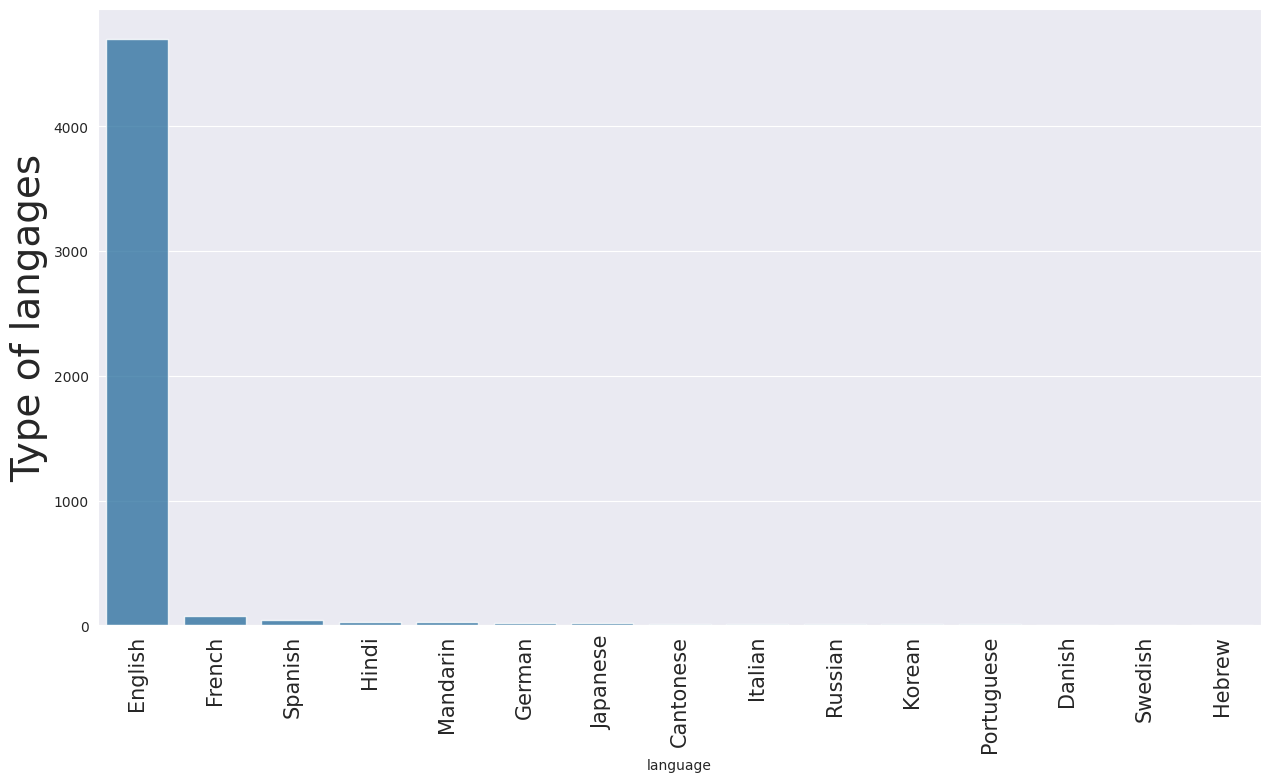

In [ ]:
sns.set_style("darkgrid")
ls = df['language'].value_counts().head(15).sort_values(ascending=False)
plt.figure(figsize=(15,8))
temp = sns.barplot(x=ls.index, y=ls.values, alpha=0.8)
plt.ylabel('COUNT', fontsize=14)
plt.ylabel('Type of langages', fontsize=28)
temp.set_xticklabels(rotation=90, labels = ls.index, fontsize=15)
plt.show()

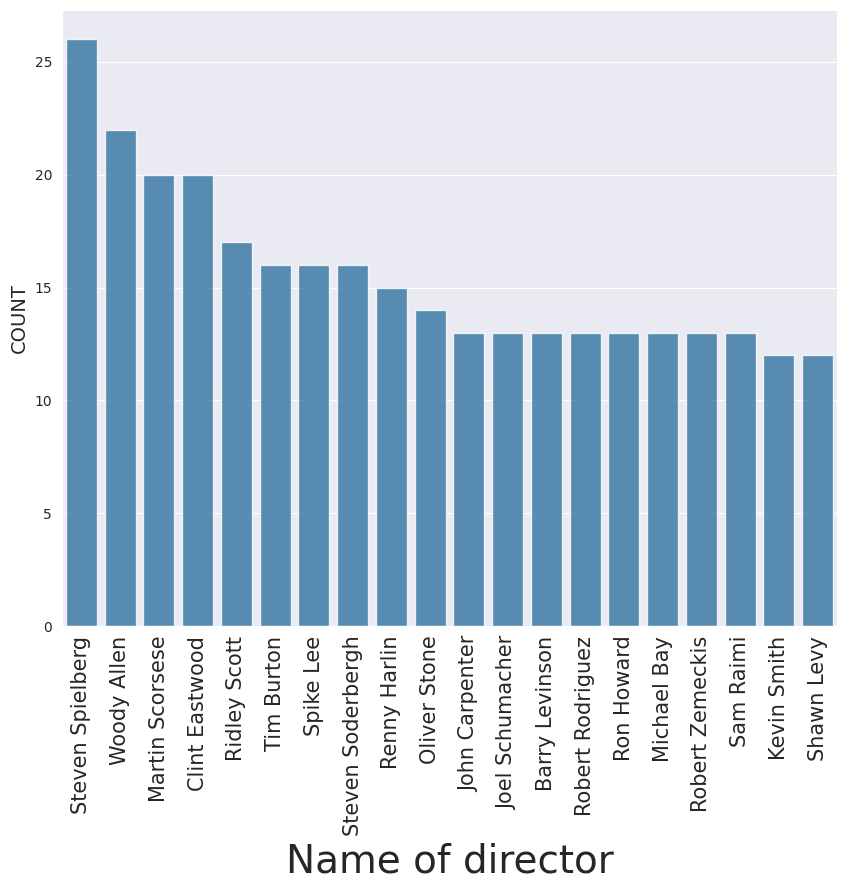

In [ ]:
sns.set_style("darkgrid")
ls = df['director_name'].value_counts().head(20).sort_values(ascending=False)

plt.figure(figsize = (10,8))
temp = sns.barplot(x=ls.index, y=ls.values, alpha=0.8)
plt.ylabel('COUNT', fontsize=14)
plt.xlabel('Name of director', fontsize=28)
temp.set_xticklabels(rotation=90, labels=ls.index, fontsize=15)
plt.show()

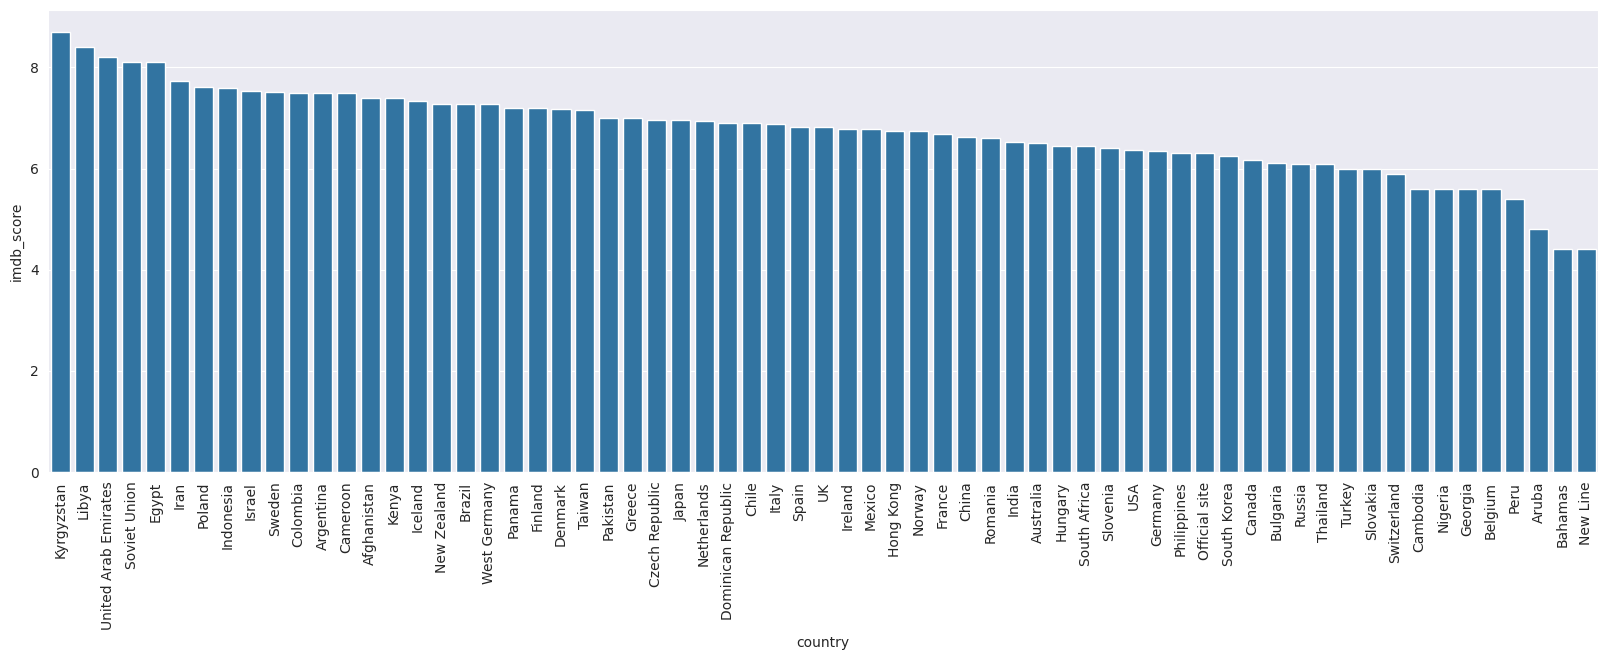

In [ ]:
plt.figure(figsize=(20,6))
sns.barplot(df.groupby('country')['imdb_score'].mean().sort_values(ascending=False)
)
plt.xticks(rotation=90)
plt.show()

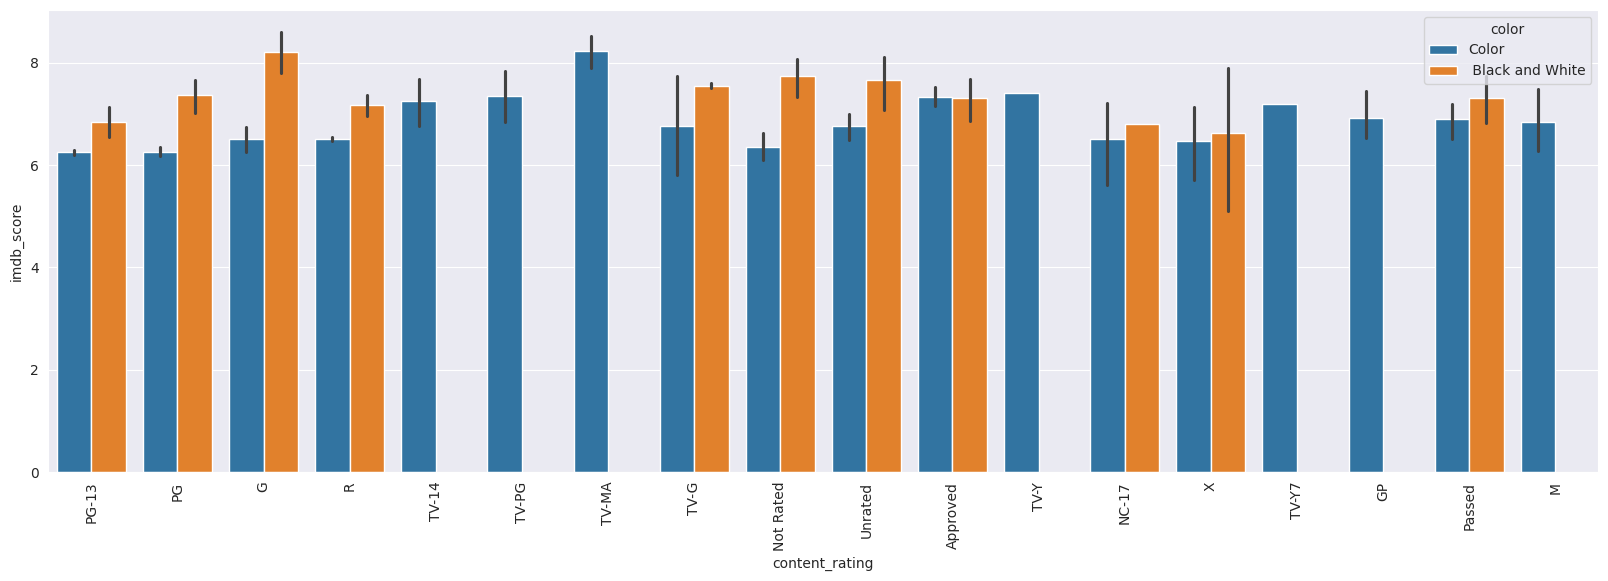

In [ ]:
plt.figure(figsize=(20,6))
sns.barplot(x = 'content_rating', y = 'imdb_score', hue='color', data=df)
plt.xticks(rotation=90)
plt.show()

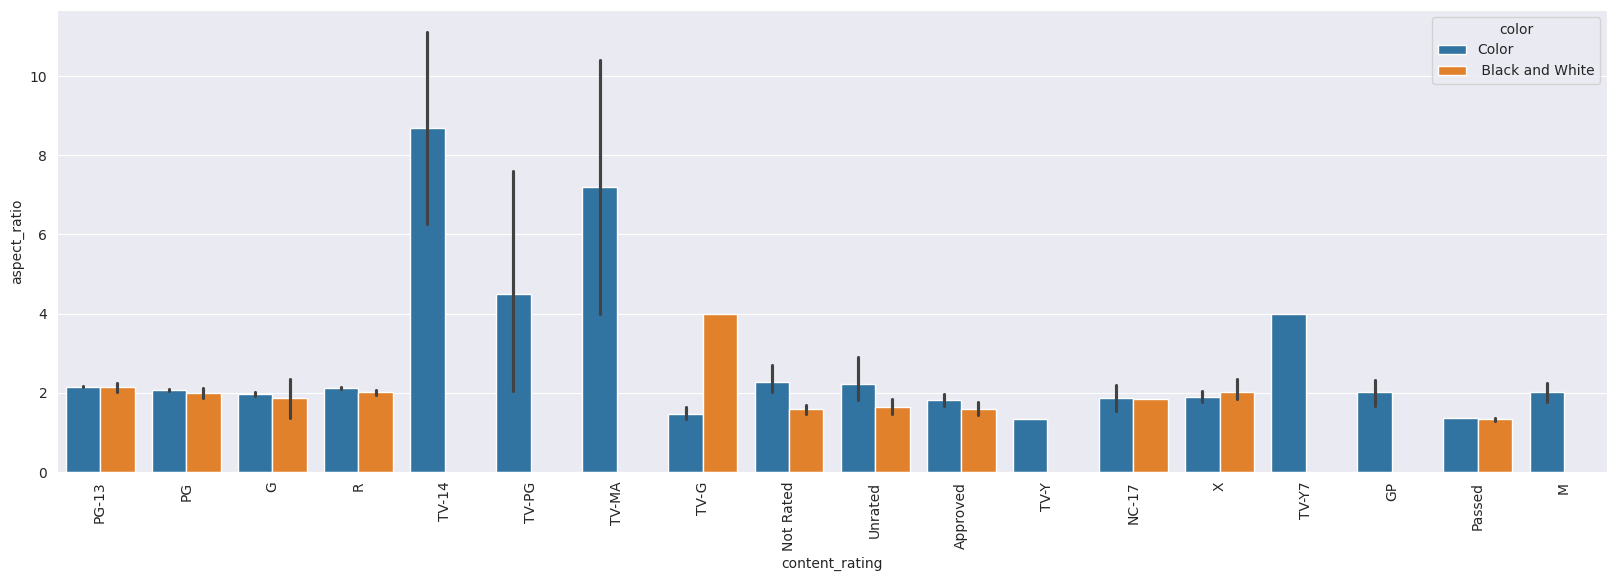

In [ ]:
plt.figure(figsize=(20,6))
sns.barplot(x = 'content_rating', y = 'aspect_ratio', hue = 'color', data=df)
plt.xticks(rotation=90)
plt.show()

In [ ]:
df.groupby('content_rating')['aspect_ratio'].mean().sort_values(ascending=False)

,aspect_ratio
content_rating,
TV-14,8.683103
TV-MA,7.652632
TV-PG,4.492500
TV-Y7,4.000000
PG-13,2.151456
R,2.118677
Unrated,2.110370
Not Rated,2.101739
PG,2.061250


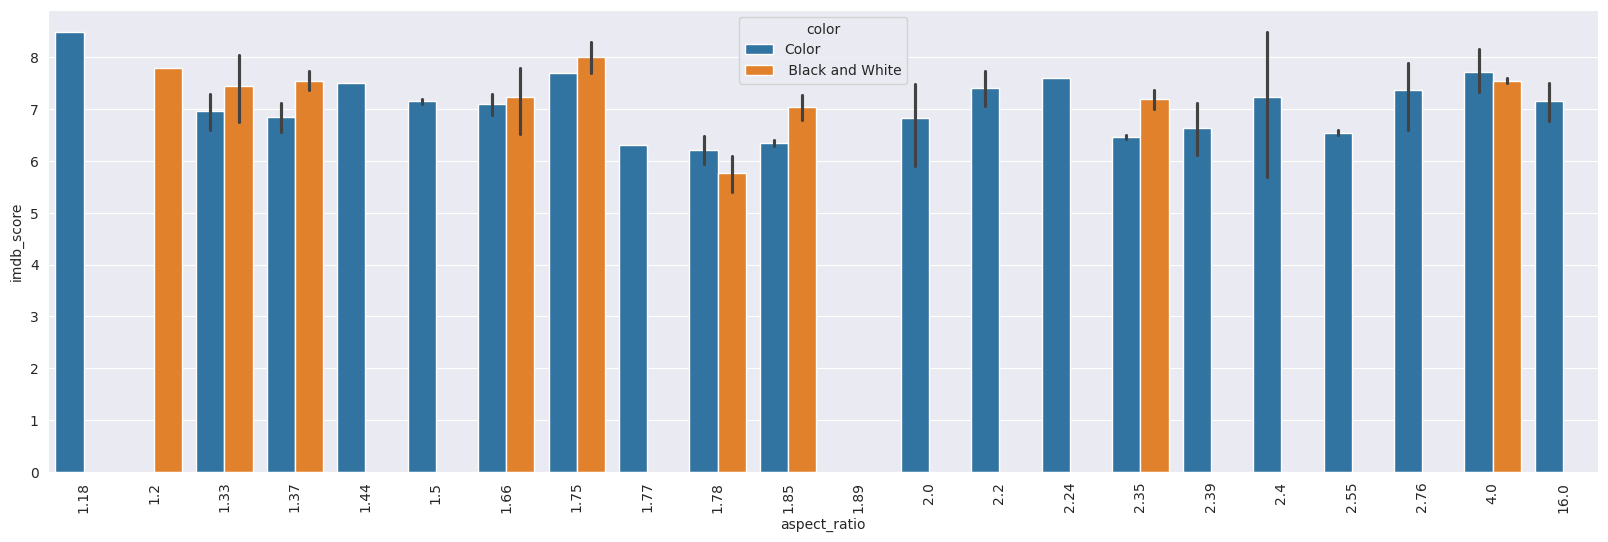

In [ ]:
plt.figure(figsize=(20,6))
sns.barplot(x = 'aspect_ratio', y= 'imdb_score', hue='color', data=df)
plt.xticks(rotation=90)
plt.show()

In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
color,0
director_name,0
num_critic_for_reviews,0
duration,0
director_facebook_likes,0
actor_3_facebook_likes,0
actor_2_name,0
actor_1_facebook_likes,0
gross,0
genres,0


In [ ]:
df = df.drop(columns = ['movie_imdb_link', 'color', 'movie_title','facenumber_in_poster', 'plot_keywords',
                    'actor_3_name','movie_imdb_link','aspect_ratio','language'])

In [ ]:
df

,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,num_voted_users,cast_total_facebook_likes,num_user_for_reviews,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,movie_facebook_likes
0,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,CCH Pounder,886204,4834,3054.0,USA,PG-13,237000000.0,2009.0,936.0,7.9,33000
1,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,Johnny Depp,471220,48350,1238.0,USA,PG-13,300000000.0,2007.0,5000.0,7.1,0
2,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,Christoph Waltz,275868,11700,994.0,UK,PG-13,245000000.0,2015.0,393.0,6.8,85000
3,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,Tom Hardy,1144337,106759,2701.0,USA,PG-13,250000000.0,2012.0,23000.0,8.5,164000
5,Andrew Stanton,462.0,132.0,475.0,530.0,Samantha Morton,640.0,73058679.0,Action|Adventure|Sci-Fi,Daryl Sabara,212204,1873,738.0,USA,PG-13,263700000.0,2012.0,632.0,6.6,24000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5026,Olivier Assayas,81.0,110.0,107.0,45.0,Béatrice Dalle,576.0,136007.0,Drama|Music|Romance,Maggie Cheung,3924,776,39.0,France,R,4500.0,2004.0,133.0,6.9,171
5027,Jafar Panahi,64.0,90.0,397.0,0.0,Nargess Mamizadeh,5.0,673780.0,Drama,Fereshteh Sadre Orafaiy,4555,5,26.0,Iran,Not Rated,10000.0,2000.0,0.0,7.5,697
5033,Shane Carruth,143.0,77.0,291.0,8.0,David Sullivan,291.0,424760.0,Drama|Sci-Fi|Thriller,Shane Carruth,72639,368,371.0,USA,PG-13,7000.0,2004.0,45.0,7.0,19000
5035,Robert Rodriguez,56.0,81.0,0.0,6.0,Peter Marquardt,121.0,2040920.0,Action|Crime|Drama|Romance|Thriller,Carlos Gallardo,52055,147,130.0,USA,R,7000.0,1992.0,20.0,6.9,0


# Label Encoding Categorical Data

In [ ]:
cat_cols = ['director_name','actor_2_name','genres','actor_1_name','actor_3_name','language','country','content_rating']
le = LabelEncoder()


In [ ]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
for i in cat_cols:
  df[i] = le.fit_transform(df[i])
df.dtypes

,0
director_name,int64
num_critic_for_reviews,float64
duration,float64
director_facebook_likes,float64
actor_3_facebook_likes,float64
actor_2_name,int64
actor_1_facebook_likes,float64
gross,float64
genres,int64
actor_1_name,int64


# Distribution Plot


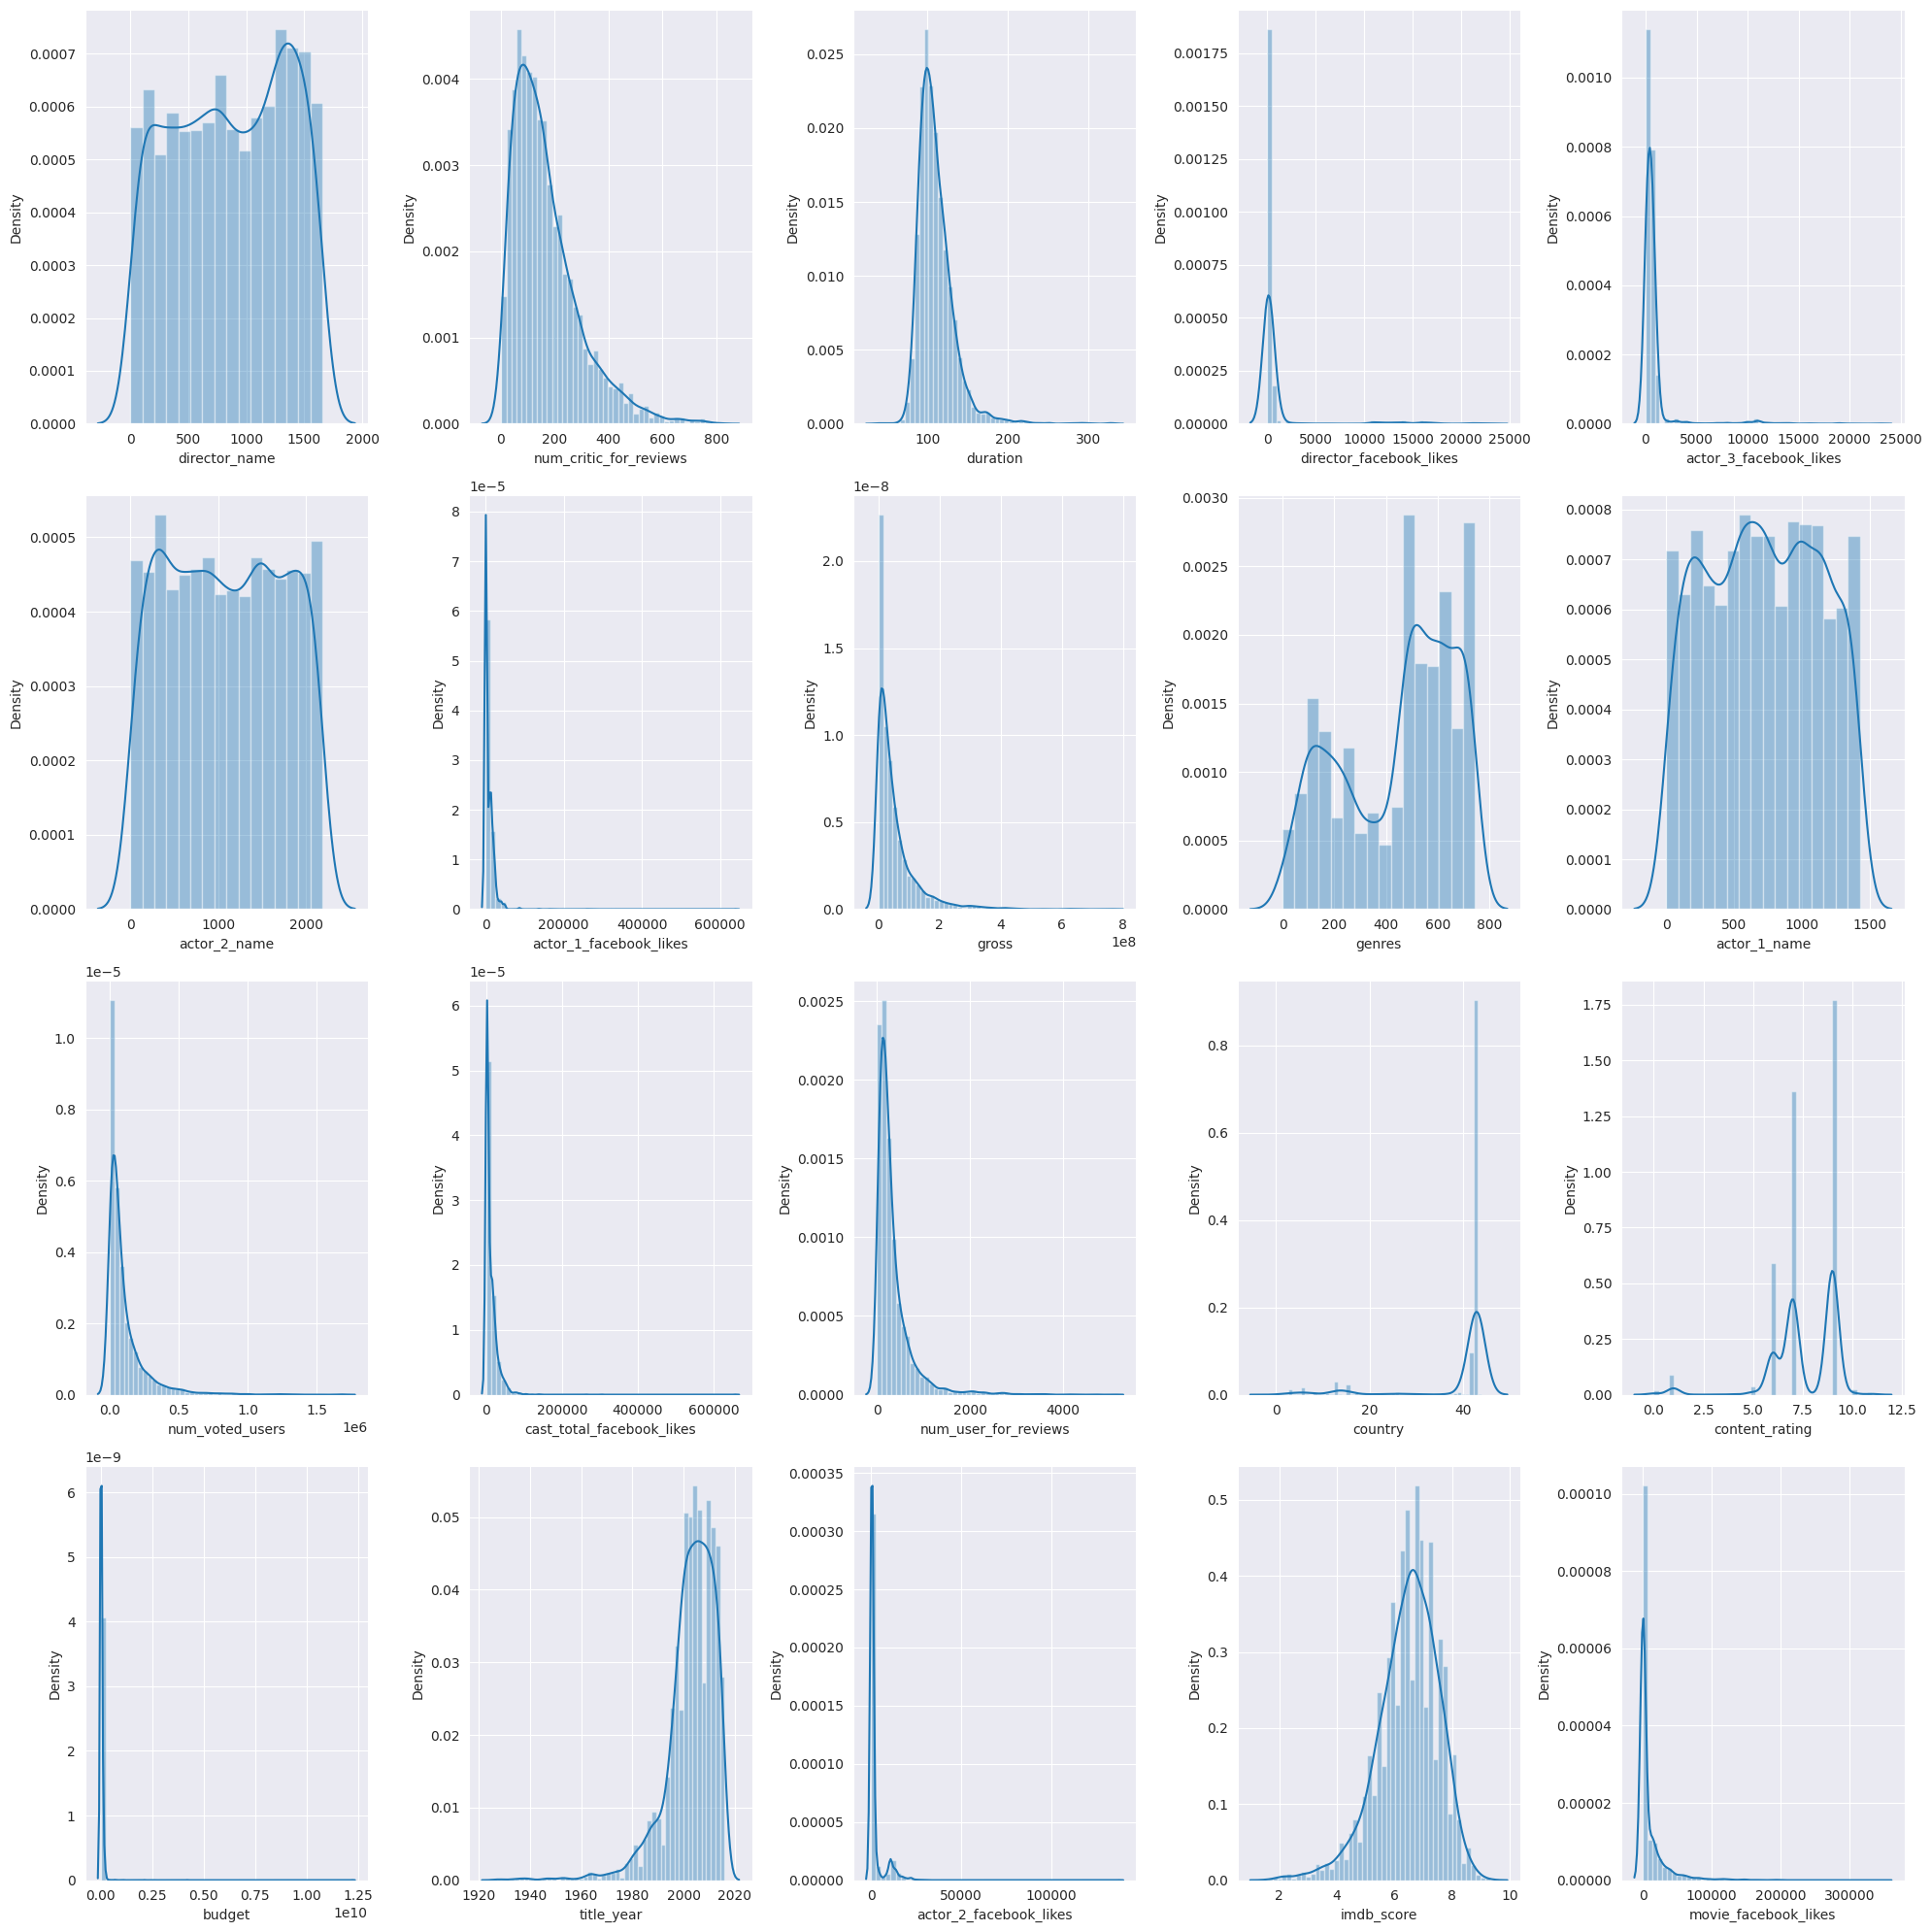

In [ ]:
rows = 4
cols = 5
fig, ax = plt.subplots(nrows = rows, ncols = cols, figsize = (20,20))
col = df.columns
index = 0

for i in range(rows):
  for j in range(cols):
    sns.distplot(df[col[index]], ax=ax[i][j])
    index = index+1

plt.tight_layout()

# Log Transformation


In [ ]:
skewed_features = ['director_name', 'num_critic_for_reviews', 'duration',
       'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name',
       'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name',
       'num_voted_users', 'cast_total_facebook_likes', 'num_user_for_reviews',
       'country', 'content_rating', 'budget', 'title_year',
       'actor_2_facebook_likes', 'imdb_score', 'movie_facebook_likes']

In [ ]:
for i in skewed_features:
  df[i]=np.log(df[i]+1)

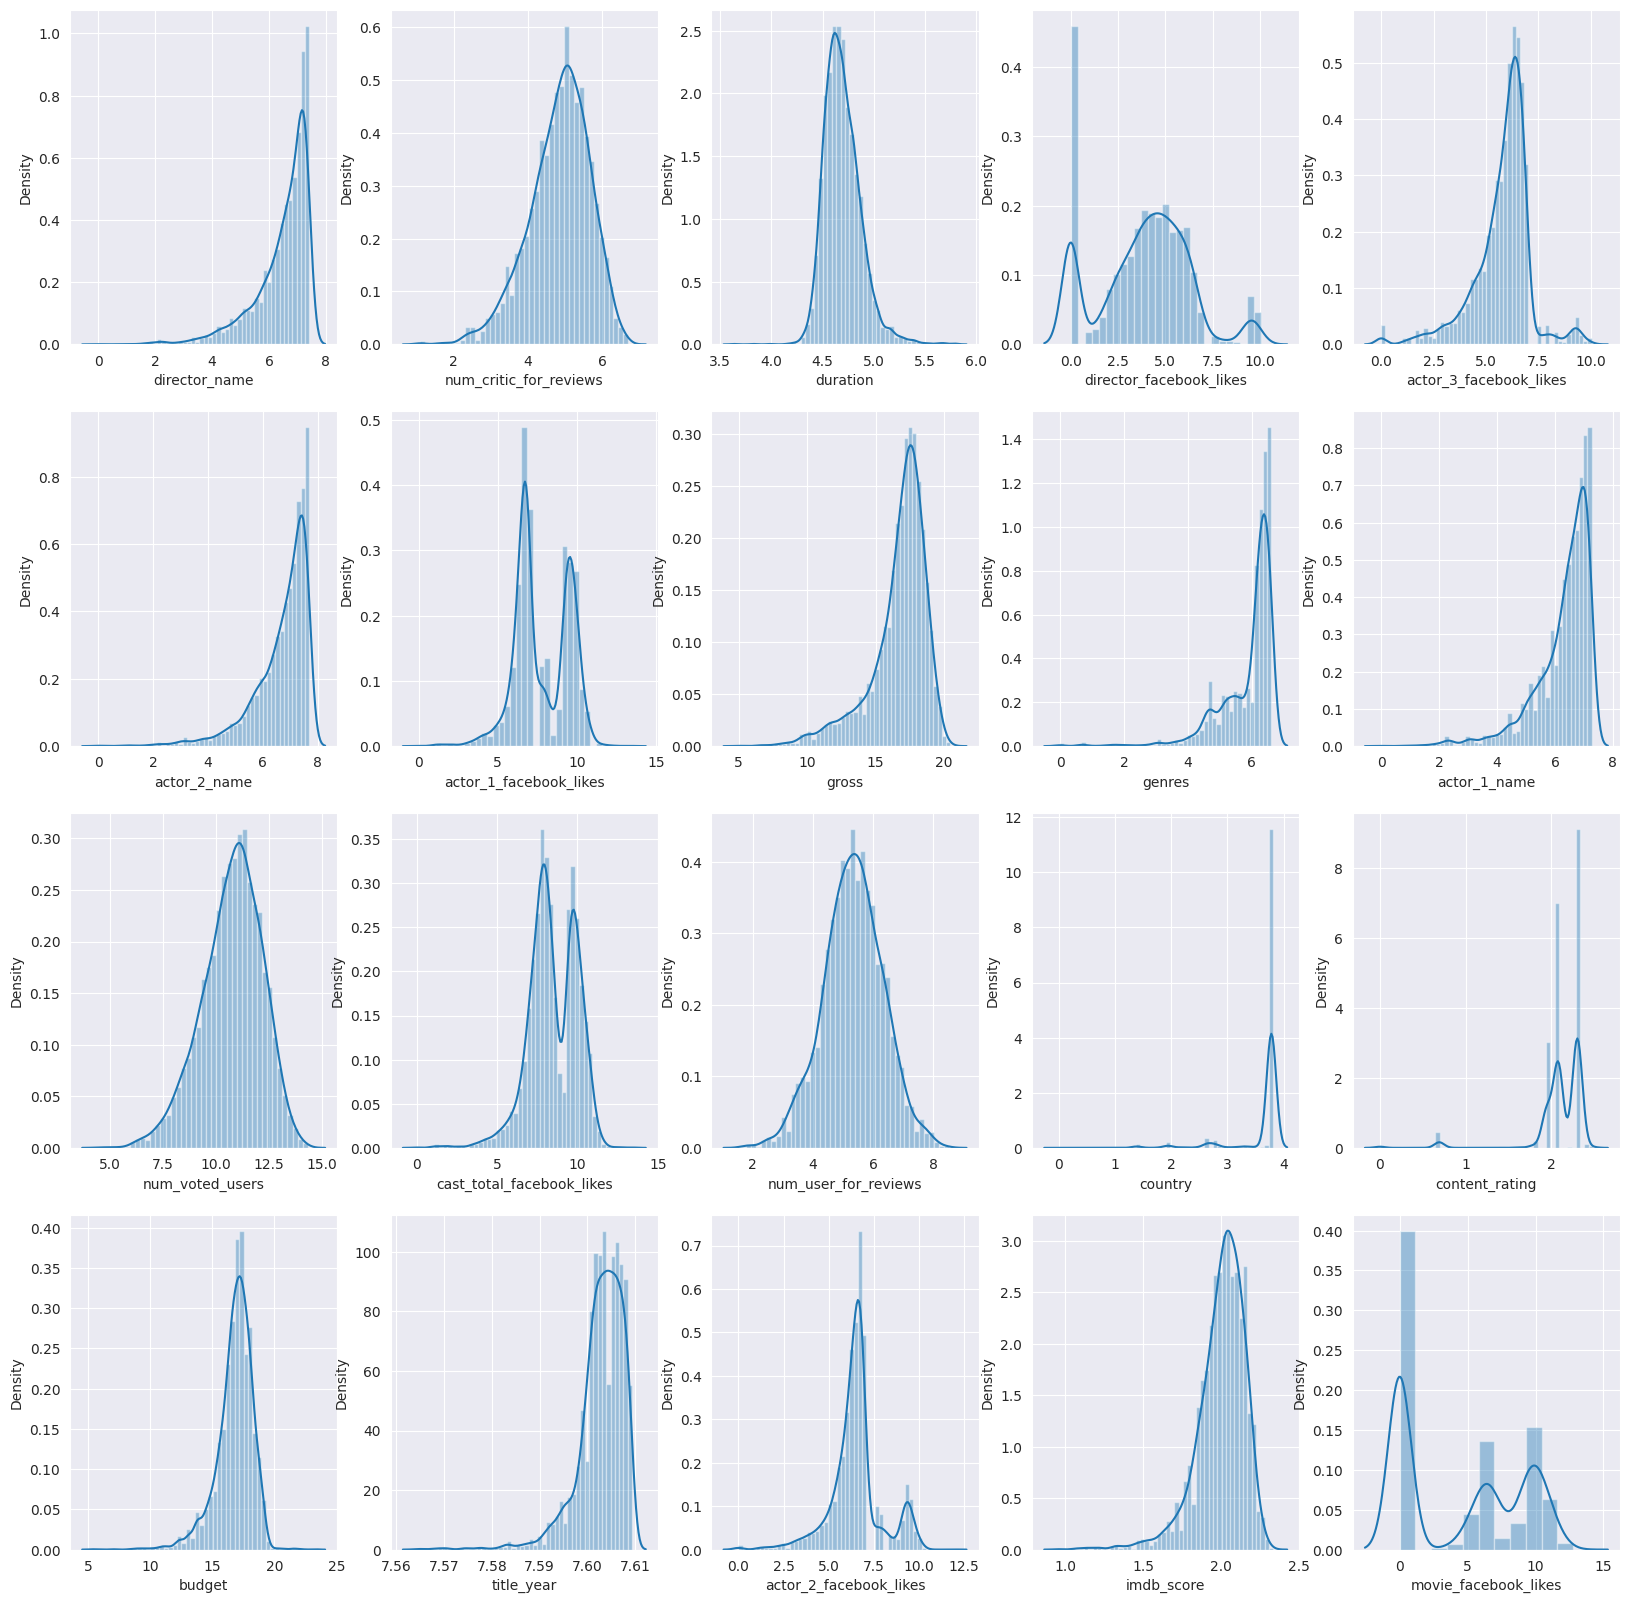

In [ ]:
rows = 4
cols = 5

fig, ax = plt.subplots(nrows = rows, ncols = cols, figsize = (20,20))
col = df.columns
index = 0

for i in range(rows):
  for j in range(cols):
    sns.distplot(df[col[index]], ax=ax[i][j])
    index=index+1

plt.show()

# Splitting dataset


In [ ]:
X = df.drop(labels=['imdb_score'], axis=1)
y = df['imdb_score']
X.head()

,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,num_voted_users,cast_total_facebook_likes,num_user_for_reviews,country,content_rating,budget,title_year,actor_2_facebook_likes,movie_facebook_likes
0,6.431331,6.584791,5.187386,0.000000,6.752270,6.909753,6.908755,20.449494,4.521789,5.247024,13.694704,8.483636,8.024535,3.78419,2.079442,19.283571,7.605890,6.842683,10.404293
1,6.289716,5.713733,5.135798,6.335054,6.908755,7.372746,10.596660,19.550159,4.454347,6.532334,13.063082,10.786242,7.122060,3.78419,2.079442,19.519293,7.604894,8.517393,0.000000
2,7.240650,6.401917,5.003946,0.000000,5.087596,7.492760,9.305741,19.114199,4.682131,5.556828,12.527681,9.367430,6.902743,3.76120,2.079442,19.316769,7.608871,5.976351,11.350418
3,5.529429,6.701960,5.105945,9.998843,10.043293,5.942799,10.203629,19.920595,5.497168,7.200425,13.950337,11.578339,7.901748,3.78419,2.079442,19.336971,7.607381,10.043293,12.007628
5,4.143135,6.137727,4.890349,6.165418,6.274762,7.515889,6.463029,18.106774,4.663439,5.777652,12.265308,7.535830,6.605298,3.78419,2.079442,19.390323,7.607381,6.450470,10.085851


In [ ]:
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2, random_state= 40)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3004, 19) (751, 19) (3004,) (751,)


# **Machine Learning**

### Linear Regression


In [ ]:
lm = LinearRegression()
lm = lm.fit(X_train, y_train)

train_pred = lm.predict(X_train)

test_pred = lm.predict(X_test)

RMSE_test = np.sqrt(metrics.mean_squared_error(y_test, test_pred))
RMSE_train = np.sqrt(metrics.mean_squared_error(y_train, train_pred))
print("RMSE Training Data = ", str(RMSE_train))
print("RMSE Test Data = ", str(RMSE_test))
print()
print('RSquared value on train:', lm.score(X_train, y_train))
print('RSquared value on test:', lm.score(X_test, y_test))

RMSE Training Data =  0.1199935735876636
RMSE Test Data =  0.12031121642892623

RSquared value on train: 0.41119002122665094
RSquared value on test: 0.38764887857535324


In [ ]:
errors = abs(test_pred - y_test)

In [ ]:
mape = 100 * (errors / y_test)

accuracy = 100 - np.mean(mape)
print("Accuracy:", round(accuracy, 2), '%.')

Accuracy: 95.43 %.


# Random Forest Regressor

In [ ]:
RF = RandomForestRegressor().fit(X_train, y_train)

train_preds1 = RF.predict(X_train)

test_preds1 = RF.predict(X_test)

RMSE_train = (np.sqrt(metrics.mean_squared_error(y_train, train_preds1)))
RMSE_test = (np.sqrt(metrics.mean_squared_error(y_test, test_preds1)))
print("RMSE TrainingData = ", str(RMSE_train))
print("RMSE_test = ", str(RMSE_test))
print()
print('RSquared value on train:', RF.score(X_train, y_train))
print('RSquared value on test:', RF.score(X_test, y_test))

RMSE TrainingData =  0.041724045707903466
RMSE_test =  0.0998932735056305

RSquared value on train: 0.9288078659361858
RSquared value on test: 0.5778558529196429


In [ ]:
errors = abs(test_preds1 - y_test)

In [ ]:
mape = 100 * (errors / y_test)

accuracy = 100 - np.mean(mape)
print('Accuracy:', round(accuracy, 2), '%')

Accuracy: 96.28 %


# K-Nearest Neighbours

In [ ]:
knn = KNeighborsRegressor()
knn.fit(X_train, y_train)

train_preds2 = knn.predict(X_train)

test_preds2 = knn.predict(X_test)

RMSE_train = np.sqrt(metrics.mean_squared_error(y_train, train_preds2))
RMSE_test = np.sqrt(metrics.mean_squared_error(y_test, test_preds2))
print('RMSE TestData = ', str(RMSE_test))
print('RMSE TrainData = ', str(RMSE_train))
print()
print('RSquared value on train:', knn.score(X_train, y_train))
print('RSquared value on test:', knn.score(X_test, y_test))

RMSE TestData =  0.13247140608619523
RMSE TrainData =  0.10862429686145442

RSquared value on train: 0.5174824177279325
RSquared value on test: 0.2576092125305033


1. What each metric means
RMSE — Root Mean Squared Error

RMSE measures the average prediction error.

Lower RMSE = better model.

Actual value     Predicted value
10               10.2
20               19.8
30               29.5
The smaller the differences between actual and predicted values, the lower the RMSE.

R² — R-Squared

R² tells you how much variation in the target variable the model can explain.

R² ranges roughly from:
1.0  → perfect
0.8  → very good
0.6  → good/moderate
0.4  → moderate
0.2  → weak
0.0  → explains almost nothing
< 0   → worse than a simple mean prediction
R² = 0.57 - means the model explains approximately 57% of the variation in the target.

###Linear Regression:
RMSE Train = 0.11999
RMSE Test  = 0.12031

R² Train = 0.4112
R² Test  = 0.3876

Accuracy = 95.43%

Train and test RMSE are almost identical:0.11999 → 0.12031.

That's actually a good sign.

There isn't a large gap between training and testing performance.

R2:
Train = 41.12%
Test  = 38.76%

So Linear Regression explains only around 39% of the variation on unseen data.

###Conclusion
Linear Regression is not severely overfitting, but its predictive power is relatively limited.

Good generalization
        ↓
But
        ↓
Moderate/weak predictive power

##Random Forest
RMSE Train = 0.04177
RMSE Test  = 0.10015

R² Train = 0.9286
R² Test  = 0.5756

Accuracy = 96.3%

Training performance:
RMSE = 0.0418
R² = 92.86%

That's extremely strong on the training data.

But look at the test data:
RMSE = 0.1002
R² = 57.56%

There is a significant difference.
Train R² = 92.86%
Test R²  = 57.56%
             ↓
       Large performance drop

This indicates overfitting.

The Random Forest has learned the training data very well, but doesn't perform nearly as well on unseen data.

##KNN

RMSE Train = 0.10862
RMSE Test  = 0.13247

R² Train = 0.5175
R² Test  = 0.2576

Training:
R² = 51.75%

Testing:
R² = 25.76%
That's a fairly large drop.

Test RMSE = 0.13247
which is the highest test RMSE among your three models.



------------------------------------
Don't use "accuracy" for a normal regression problem.

So instead of saying:

Random Forest accuracy = 96.3%

say:

Random Forest achieved an R² of 0.576 and RMSE of 0.100 on the test dataset.

------------------------------------
**What I would say in an interview**

You can explain your results like this:

"I evaluated Linear Regression, Random Forest, and KNN using RMSE and R² on both training and testing datasets. Random Forest performed best on the test set, achieving an RMSE of approximately 0.10 and an R² of 0.576. However, its training R² was 0.929 compared with 0.576 on the test set, indicating some overfitting. Linear Regression was more stable between training and test performance but had lower predictive power. KNN had the weakest test performance with an R² of 0.258 and RMSE of 0.132. Therefore, among these three models, Random Forest is the best candidate, but I would further tune it and validate it using cross-validation to reduce overfitting."

In [ ]:
data_download = X+y

In [ ]:
pd.concat([X,y], axis=1).to_csv('data_download.csv', index=False)